# Bias and varience

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(42)

X= np.linspace(0,10,40).reshape(-1,1)

y=2+0.5*X[:,0]**2+np.random.normal(0,5,40)


In [ ]:
X

array([[ 0.        ],
       [ 0.25641026],
       [ 0.51282051],
       [ 0.76923077],
       [ 1.02564103],
       [ 1.28205128],
       [ 1.53846154],
       [ 1.79487179],
       [ 2.05128205],
       [ 2.30769231],
       [ 2.56410256],
       [ 2.82051282],
       [ 3.07692308],
       [ 3.33333333],
       [ 3.58974359],
       [ 3.84615385],
       [ 4.1025641 ],
       [ 4.35897436],
       [ 4.61538462],
       [ 4.87179487],
       [ 5.12820513],
       [ 5.38461538],
       [ 5.64102564],
       [ 5.8974359 ],
       [ 6.15384615],
       [ 6.41025641],
       [ 6.66666667],
       [ 6.92307692],
       [ 7.17948718],
       [ 7.43589744],
       [ 7.69230769],
       [ 7.94871795],
       [ 8.20512821],
       [ 8.46153846],
       [ 8.71794872],
       [ 8.97435897],
       [ 9.23076923],
       [ 9.48717949],
       [ 9.74358974],
       [10.        ]])

In [ ]:
y

array([ 4.48357077,  1.3415516 ,  5.36993513,  9.91100727,  1.35520288,
        1.65114296, 11.07949603,  7.44795603,  1.7565071 ,  7.37552211,
        2.97022252,  3.64899752,  7.94353917, -2.01084567, -0.18145964,
        6.58501206,  5.35136051, 13.07156539,  8.1107672 ,  6.80567413,
       22.47748776, 15.36815992, 18.24822616, 12.26613415, 18.21299762,
       23.10030657, 18.46725434, 27.84298713, 24.76932463, 28.18781659,
       28.57726576, 42.85244944, 35.59457831, 32.51026192, 44.11403948,
       36.16534125, 45.64786827, 37.20493669, 42.8278403 , 52.98430618])

In [ ]:
from math import degrees
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

degrees = [1,2,10]

for degree in degrees:
  model = make_pipeline(
      PolynomialFeatures(degree=degree,include_bias=False),
      LinearRegression()
      )
  model.fit(X_train,y_train)

  train_prediction = model.predict(X_train)
  test_prediction = model.predict(X_test)

  train_mse = mean_squared_error(y_train,train_prediction)
  test_mse = mean_squared_error(y_test,test_prediction)


  print(f"Polynomial degree: {degree}")
  print(f"Train MSE: {train_mse:.2f}")
  print(f"Test MSE: {test_mse:.2f}")
  print()

Polynomial degree: 1
Train MSE: 42.90
Test MSE: 42.99

Polynomial degree: 2
Train MSE: 20.44
Test MSE: 19.79

Polynomial degree: 10
Train MSE: 12.89
Test MSE: 95.21



polynomial degree:1
simple model
high training error, high testing error
Underfitting

polynomial degree:2
low training error, low testing error
goodfit

polynomial degree:10
complex model
low training error, high testing error
overfitting


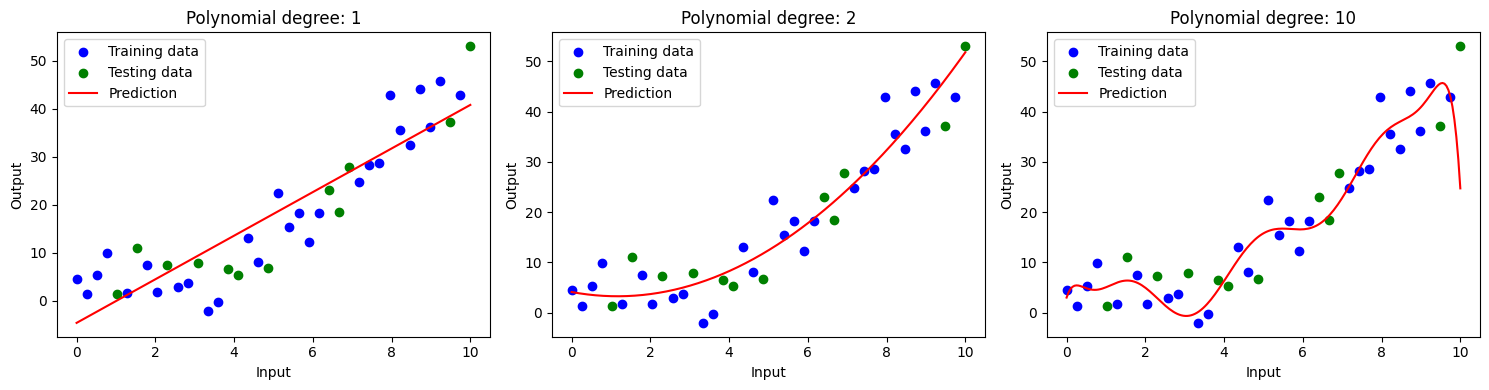

In [ ]:
X_plot =np.linspace(0,10,200).reshape(-1,1)

plt.figure(figsize=(15,4))

for index, degree in enumerate(degrees):
  model=make_pipeline(
      PolynomialFeatures(degree=degree,include_bias=False),
      LinearRegression()
  )
  model.fit(X_train,y_train)

  y_plot = model.predict(X_plot)

  plt.subplot(1,3,index+1)
  plt.scatter(X_train,y_train,color="blue",label="Training data")
  plt.scatter(X_test,y_test,color='green',label = "Testing data")
  plt.plot(X_plot,y_plot,color='red',label = "Prediction")

  plt.title(f"Polynomial degree: {degree}")
  plt.xlabel("Input")
  plt.ylabel("Output")
  plt.legend()

plt.tight_layout()
plt.show()

training error decreases as model complexity increses

validation error genreally behaves differently:
it is high for very simple models because of underfitting.
it decreaces when model